In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from itertools import cycle

from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [2]:
def ODE_system_solver(f, y0, t0, final_t, step = 1e-4):

    ts = np.arange(t0, final_t, step)
    ys = np.empty((len(ts), len(y0)), dtype=np.float32)
    ys[0] = y0

    for i, t in enumerate(ts[:-1]):
        ys[i + 1] = ys[i] + f(t, ys[i]) * step

    return ts, ys

In [3]:
L = 1.0
Nx = 100
dx = L / Nx
phi = 0.2
u = 1e-6
mu_w = 1e-3
mu_g = 1e-5
S_wc = 0.2
S_gr = 0.1

S_inicial = 0.2
S_left = 0.9

In [4]:
# @nb.njit
def S_n(S):
    return (S - S_wc) / (1 - S_wc - S_gr)

# @nb.njit
def k_rw(S):
    return ((S - S_wc) / (1 - S_wc - S_gr)) ** 4

# @nb.njit
def k_rg(S):
    return ((1 - S - S_gr) / (1 - S_wc - S_gr)) ** 2

# @nb.njit
def f_w(S):
    lambda_w = k_rw(S) / mu_w
    lambda_g = k_rg(S) / mu_g
    return lambda_w / (lambda_w + lambda_g)

# @nb.njit
def f(S):
    return f_w(S) * u

# @nb.njit
def rhs(t, y):
    F = np.empty(y.shape[0] + 1, dtype=np.float32)
    F[0] = f(S_left)
    F[1:] = f(y)

    return -(F[1:] - F[:-1]) / (phi * dx)
    

In [5]:
def f_tilde(S):
    return S_n(S) * u

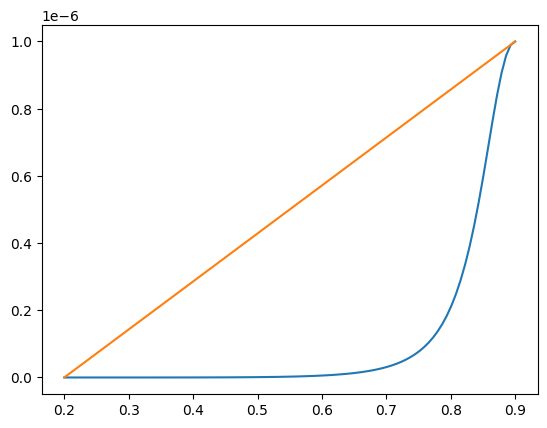

In [6]:
plt.plot(torch.linspace(0.2, 0.9, 100), f(torch.linspace(0.2, 0.9, 100)))
plt.plot(torch.linspace(0.2, 0.9, 100), f_tilde(torch.linspace(0.2, 0.9, 100)))
plt.show()

In [7]:
xs = np.linspace(0, L, Nx)
S0 = np.full(xs.shape[0], S_inicial)
dt = 150.0
T_max = 150000

ts, us = ODE_system_solver(rhs, S0, 0, T_max, dt)
Nt = len(ts)

In [8]:
N_plot = 5000

idxs_t = np.random.randint(low=0, high=us.shape[0], size=N_plot)
idxs_x = np.random.randint(low=0, high=us.shape[1], size=N_plot)

X_plot = np.stack((ts[idxs_t], xs[idxs_x]), axis=1)
u_plot = us[idxs_t, idxs_x]

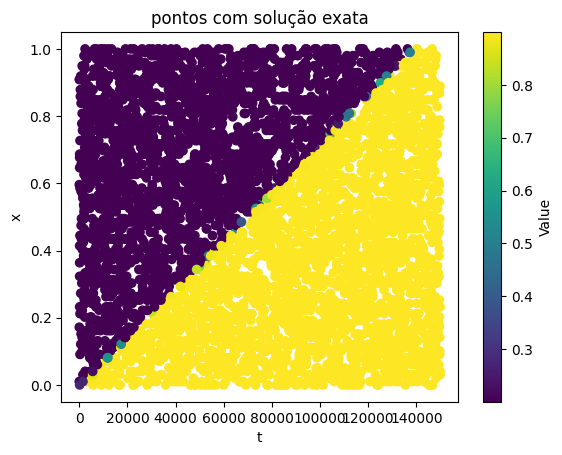

In [9]:
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=u_plot, cmap="viridis", vmin=us.min(), vmax=us.max())
plt.xlabel('t')
plt.ylabel('x')
plt.title('pontos com solução exata')
plt.colorbar(label='Value')
plt.show()

In [10]:
def f_prime(S):
    S = S.clone().detach().requires_grad_(True)
    f_val = f(S)

    return torch.autograd.grad(outputs=f_val, inputs=S, grad_outputs=torch.ones_like(f_val))[0]

In [11]:
0.8 - f_prime(torch.tensor([[0.9]])) * 80000

tensor([[0.8000]])

In [12]:
def pinn_loss(X_batch, y_fake, X_contorno, y_contorno, X_inicial, y_inicial, lambda_1 = 1.5, make_reduction=True):
    
    dy_dX = torch.autograd.grad(y_fake, X_batch, grad_outputs=torch.ones_like(y_fake), create_graph=True)[0]
    
    f_val = f(y_fake)
    df_dy = torch.autograd.grad(f_val, y_fake, grad_outputs=torch.ones_like(y_fake), create_graph=True)[0]
    
    dy_dt = dy_dX[:, :1]
    dy_dx = dy_dX[:, 1:]
    df_dx = df_dy * dy_dx # regra da cadeia

    if make_reduction:
        L_f = torch.mean((phi * dy_dt + df_dx) ** 2)
        L_b1 = torch.mean((y_inicial - 0.2) ** 2)
        L_b2 = torch.mean((y_contorno - 0.9) ** 2)
    
        return L_f + lambda_1 * (L_b1 + L_b2)
    else:
        L_f = (phi * dy_dt + df_dx) ** 2
        L_b1 = (y_inicial - 0.2) ** 2
        L_b2 = (y_contorno - 0.9) ** 2

        return L_f, L_b1, L_b2

In [13]:
def sample_points(N_colocacao, N_contorno, N_inicial, max_t = T_max):
    X_colocacao = torch.cat([
        (1 - torch.rand(N_colocacao, 1)) * max_t,
        torch.rand(N_colocacao, 1)
    ], dim = 1)

    X_contorno = torch.cat([
        (1 - torch.rand(N_contorno, 1)) * max_t, 
        torch.zeros(N_contorno, 1)
    ], dim = 1)

    X_inicial = torch.cat([
        torch.zeros(N_inicial, 1),
        torch.rand(N_inicial, 1)
    ], dim = 1)

    return X_colocacao, X_contorno, X_inicial

In [14]:
def replace_least_error_points(points, new_points, errors):

    N_todos = points.shape[0]
    N_novos = new_points.shape[0]
    N_resto = N_todos - N_novos
    
    idxs = np.argpartition(-errors.detach().numpy(), N_resto, axis=0).flatten()
    idxs = idxs[:N_resto]

    return torch.cat((points[idxs], new_points), axis=0)    

In [15]:
def resample_ozanski(X_colocacao, X_contorno, X_inicial, model, max_t = T_max, perc=0.15, perc_boundary=0.1, lambda_1=0.1):

    X_todos = torch.cat((X_contorno, X_inicial, X_colocacao), dim=0).requires_grad_(True)
    
    N_colocacao = X_colocacao.shape[0]
    N_contorno = X_contorno.shape[0]
    N_inicial = X_inicial.shape[0]

    y_fake = model(X_todos)
    y_fake_contorno = y_fake[0:N_contorno, :]
    y_fake_inicial = y_fake[N_contorno:N_contorno + N_inicial, :]

    L_f, L_b1, L_b2 = pinn_loss(X_todos, y_fake, X_contorno, y_fake_contorno, X_inicial, y_fake_inicial, make_reduction=False)

    loss_contorno = L_f[0:N_contorno, :] + lambda_1 * L_b2
    loss_inicial = L_f[N_contorno:N_contorno + N_inicial, :] + lambda_1 * L_b1
    loss_colocacao = L_f[N_contorno + N_inicial:, :]

    X_novos_colocacao, X_novos_contorno, X_novos_inicial = sample_points(int(N_colocacao * perc), int(N_contorno * perc_boundary), int(N_inicial * perc_boundary), max_t)

    X_final_colocacao = replace_least_error_points(X_colocacao, X_novos_colocacao, loss_colocacao)
    X_final_contorno = replace_least_error_points(X_contorno, X_novos_contorno, loss_contorno)
    X_final_inicial = replace_least_error_points(X_inicial, X_novos_inicial, loss_inicial)

    return X_final_colocacao, X_final_contorno, X_final_inicial

In [16]:
def discontinuity_indicator(points, model):
    
    W, M, C = 10.0, -12.0, -1.0

    with torch.no_grad():
        approx_Us = model(points).squeeze()
    lam = f_prime(approx_Us) / u

    # 0.5 since our points are equally spaced
    lam_L = 0.5 * (lam[:, :-2] + lam[:, 1:-1])
    lam_R = 0.5 * (lam[:, 1:-1] + lam[:, 2:])

    # skipped the sigmoid because it isn't really necessary
    out = W * (lam_L - lam_R) + M * dx + C
    
    indicator = np.zeros((Nt, Nx), dtype=np.bool)

    # in the paper, they proposed to use sigmoid(out) > 0.5 <=> out > 0
    # I found that to be too little, and it would give too many false positives
    indicator[:, 1:-1] = 1.0 / (1.0 + torch.exp(-out))

    return indicator

In [34]:
def discontinuity_indicator_point(model, t, x, dx, W=10.0, M=-12.0, C=-1.0,):
    
    pts = torch.stack([
        torch.tensor([t, x - dx]),
        torch.tensor([t, x]),
        torch.tensor([t, x + dx]),
    ])

    u_vals = model(pts).squeeze()

    lam = f_prime(u_vals) / u
    lam_L = 0.5 * (lam[0] + lam[1])
    lam_R = 0.5 * (lam[1] + lam[2])

    out = torch.sigmoid(W * (lam_L - lam_R) + M * dx + C)

    return out

In [35]:
def shock_tracking_loss(model, t, x, dt, dx, max_t = T_max, min_prob=0.85):

    loss = 0.0
    n = 0
    
    while t <= max_t:

        indicator = discontinuity_indicator_point(model, t, x, dx)
        loss = loss + (1 - indicator) ** 2
        # loss = loss - indicator
        n += 1
        if indicator < min_prob:
            break
        
        with torch.no_grad():
            u_l = model(torch.tensor([t, x - dx]))
            u_r = model(torch.tensor([t, x + dx]))

        # shock speed from Rankine-Hugoniot
        s = (f(u_r) - f(u_l)) / (u_r - u_l)

        t = t + dt
        x = x + s * dt

    return loss / n


In [19]:
class PINN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid(),
        )
    def forward(self, z):
        scale = torch.tensor([T_max, 1.0])
        z_normalized = z / scale
        return self.net(z_normalized)

In [57]:
N_colocacao = 3000
N_contorno = 500
N_inicial = 500
t_max_inicial = 500
t_max = T_max

X_colocacao, X_contorno, X_inicial = sample_points(N_colocacao, N_contorno, N_inicial, t_max)

In [58]:
n_iter = 30000

batch_size = 256
batch_contorno = batch_size // 10
batch_inicial = batch_size // 10
batch_colocacao = batch_size - batch_contorno - batch_inicial

PINN_model = PINN(2, 1, 32)

lr = 1e-3
optimizer = optim.Adam(PINN_model.parameters(), lr=lr)


N_change_points = 75

In [63]:
n_iter = 10000

In [ ]:
for it in range(n_iter):

    X_batch_colocacao = X_colocacao[torch.randint(0, N_colocacao, (batch_colocacao,))]
    X_batch_contorno = X_contorno[torch.randint(0, N_contorno, (batch_contorno,))]
    X_batch_inicial = X_inicial[torch.randint(0, N_inicial, (batch_inicial,))]
    # X_batch_colocacao, X_batch_contorno, X_batch_inicial = sample_points(batch_colocacao, batch_contorno, batch_inicial)
    
    X_batch = torch.cat((X_batch_contorno, X_batch_inicial, X_batch_colocacao), dim=0).requires_grad_(True)
    
    y_fake = PINN_model(X_batch)
    y_fake_contorno = y_fake[0:batch_contorno, :]
    y_fake_inicial = y_fake[batch_contorno:batch_contorno + batch_inicial, :]
    
    L_PINN = pinn_loss(X_batch, y_fake, X_batch_contorno, y_fake_contorno, X_batch_inicial, y_fake_inicial)
    L_PINN = L_PINN + shock_tracking_loss(PINN_model, 0, 0, 250, 0.01) * 5
    
    optimizer.zero_grad()
    L_PINN.backward()
    optimizer.step()
    

    if it % N_change_points == 0:
        # t_max = int(t_max_inicial + (T_max - t_max_inicial) / n_iter * it)
        X_colocacao, X_contorno, X_inicial = resample_ozanski(X_colocacao, X_contorno, X_inicial, PINN_model, max_t = t_max)
    
    if (it + 1) % (n_iter // 10) == 0:
        print(f"Iter {it+1}: L_PINN={L_PINN.item():.10f}")

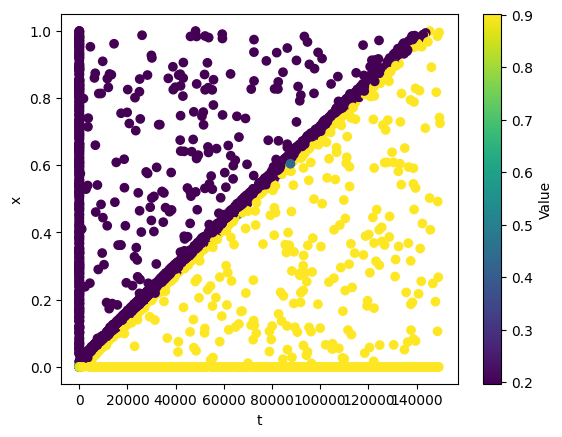

In [65]:
# X_colocacao, X_contorno, X_inicial = sample_points(3400, 300, 300)
x_plot = torch.cat((X_colocacao, X_inicial, X_contorno))
# x_plot = X_colocacao

y_pred = PINN_model(x_plot).detach().numpy()
x_plot = x_plot.detach().numpy()

plt.scatter(x_plot[:, 0], x_plot[:, 1:], c=y_pred, cmap="viridis")
plt.xlabel('t')
plt.ylabel('x')
plt.colorbar(label='Value')
plt.show()

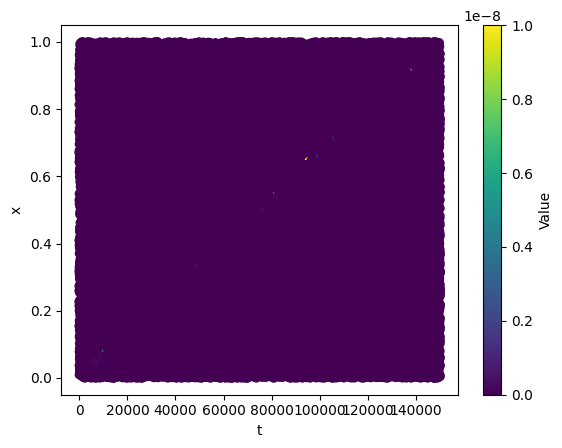

In [24]:
x_plot, *_ = sample_points(50000, 10000, 10000)
x_grad = x_plot.detach().clone().requires_grad_(True)
y_fake = PINN_model(x_grad)
L_f, *_ = pinn_loss(x_grad, y_fake, torch.empty(0, 2), torch.empty(0, 1), torch.empty(0, 2), torch.empty(0, 1), 0.0, False)

x_plot = x_plot.detach().numpy()
L_f = L_f.detach().numpy()

plt.scatter(x_plot[:, 0], x_plot[:, 1:], c=L_f, cmap="viridis", vmax=1e-8)
plt.xlabel('t')
plt.ylabel('x')
plt.colorbar(label='Value')
plt.show()

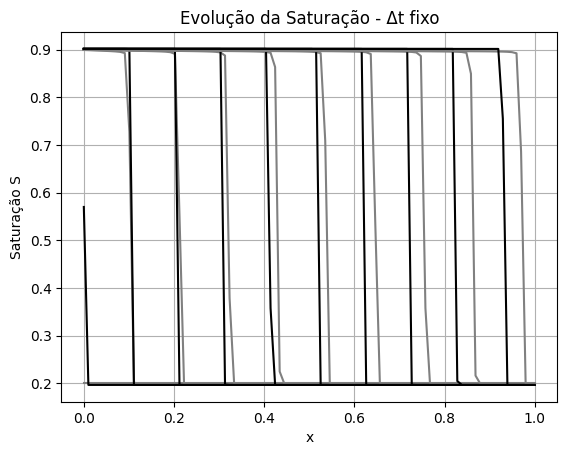

In [66]:
for idx, t in enumerate(ts[::100]):
    X = torch.tensor(np.stack([np.full(xs.shape, t), xs], axis=1), dtype=torch.float32)
    S = PINN_model(X).detach().cpu().numpy()

    # print(xs.shape, us[t].shape)
    plt.plot(xs, us[idx * 100, :], label=f't = {t/3600:.1f} h', color="gray")
    plt.plot(xs, S, label=f't = {t/3600:.1f} h', color="black")

plt.xlabel('x')
plt.ylabel('Saturação S')
plt.title('Evolução da Saturação - Δt fixo')
# plt.legend()
plt.grid(True)
plt.show()

In [26]:
with torch.no_grad():
    approx_Us = PINN_model(torch.tensor(np.stack(np.meshgrid(ts, xs, indexing="ij"), -1), dtype=torch.float32)).reshape(ts.size, xs.size)


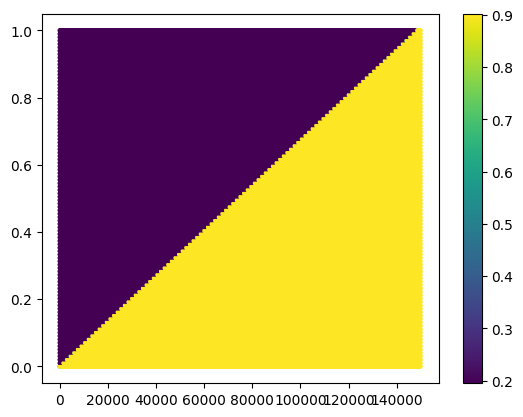

In [27]:
plt.scatter(*np.meshgrid(ts, xs, indexing="ij"),
            c=approx_Us.detach().cpu().numpy().ravel(),
            s=5)
plt.colorbar()
plt.show()

In [28]:
Nt, Nx = approx_Us.shape

# paper constants
W, M, C = 10.0, -12.0, -1.0

indicator = np.zeros((Nt, Nx), dtype=np.float32)

lam = f_prime(approx_Us) / u
lam_L = 0.5 * (lam[:, :-2] + lam[:, 1:-1])
lam_R = 0.5 * (lam[:, 1:-1] + lam[:, 2:])

out = W * (lam_L - lam_R) + M * dx + C

indicator[:, 1:-1] = out > 0

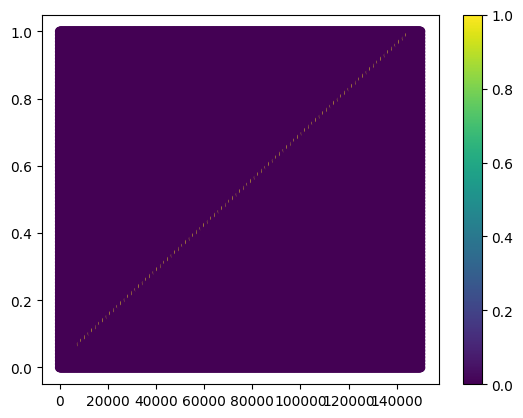

In [29]:
plt.scatter(*np.meshgrid(ts, xs, indexing="ij"),
            c=indicator.ravel())
plt.colorbar()
plt.show()

In [44]:
np.sum(indicator)

-124599.28